# EX 4A – Baseball Databank

The friend's EX 4A uses a small Student/Department/Marks table. The same filtering, sorting, grouping, correlation and charts are applied to a small real Baseball player/league/runs table.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

batting = pd.read_csv(find_data("Batting.csv"))
master = pd.read_csv(find_data("Master.csv"))

# Build a small real Baseball dataset corresponding to the original student example.
player_stats = (batting.groupby(["playerID", "lgID"], as_index=False)["R"].sum()
                .sort_values("R", ascending=False).head(6))
player_names = master[["playerID", "nameFirst", "nameLast"]].copy()
players = player_stats.merge(player_names, on="playerID", how="left")
players["Player"] = (players["nameFirst"].fillna("") + " " + players["nameLast"].fillna("")).str.strip()
players["League"] = players["lgID"].fillna("Unknown")
players["Runs"] = players["R"].astype(int)
players = players[["Player", "League", "Runs"]]

print("Baseball player dataset loaded successfully")
print("Shape:", players.shape)
players

Baseball player dataset loaded successfully
Shape: (6, 3)


,Player,League,Runs
0,Ty Cobb,AL,2246
1,Barry Bonds,NL,2227
2,Pete Rose,NL,2165
3,Babe Ruth,AL,2161
4,Hank Aaron,NL,2107
5,Willie Mays,NL,2062


In [2]:
print("Last records:")
players.tail()

Last records:


,Player,League,Runs
1,Barry Bonds,NL,2227
2,Pete Rose,NL,2165
3,Babe Ruth,AL,2161
4,Hank Aaron,NL,2107
5,Willie Mays,NL,2062


In [3]:
print("Data types:")
print(players.dtypes)
print("\nStatistical summary:")
players.describe(include="all")

Data types:
Player    object
League    object
Runs       int64
dtype: object

Statistical summary:


,Player,League,Runs
count,6,6,6.000000
unique,6,2,NaN
top,Ty Cobb,NL,NaN
freq,1,4,NaN
mean,NaN,NaN,2161.333333
std,NaN,NaN,69.732823
min,NaN,NaN,2062.000000
25%,NaN,NaN,2120.500000
50%,NaN,NaN,2163.000000
75%,NaN,NaN,2211.500000


In [4]:
filtered = players[(players["Runs"] >= players["Runs"].median()) & (players["League"] == players["League"].iloc[0])]
print("Players in the first represented league scoring at or above the median:")
filtered

Players in the first represented league scoring at or above the median:


,Player,League,Runs
0,Ty Cobb,AL,2246


In [5]:
print("Players sorted by runs:")
players.sort_values("Runs", ascending=False)

Players sorted by runs:


,Player,League,Runs
0,Ty Cobb,AL,2246
1,Barry Bonds,NL,2227
2,Pete Rose,NL,2165
3,Babe Ruth,AL,2161
4,Hank Aaron,NL,2107
5,Willie Mays,NL,2062


In [6]:
print("League-wise statistical analysis:")
players.groupby("League")["Runs"].agg(["mean","median","min","max","std"]).round(2)

League-wise statistical analysis:


,mean,median,min,max,std
League,,,,,
AL,2203.50,2203.5,2161,2246,60.10
NL,2140.25,2136.0,2062,2227,71.57


In [7]:
print("Correlation matrix:")
players[["Runs"]].corr()

Correlation matrix:


,Runs
Runs,1.0


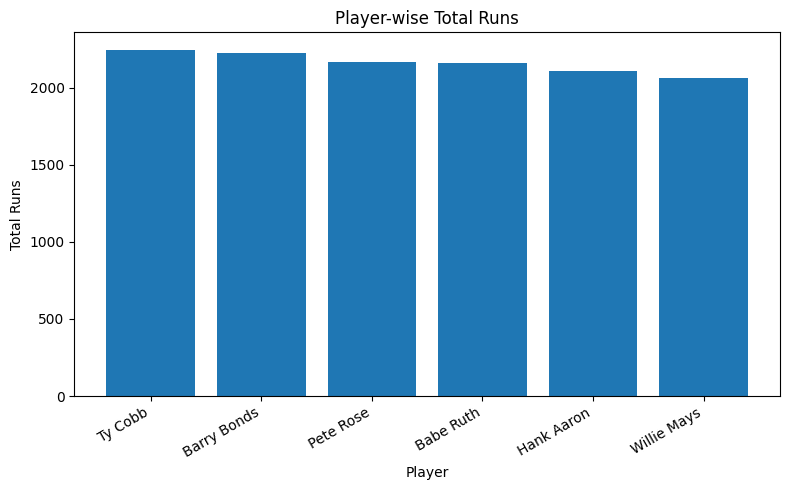

In [8]:
plt.figure(figsize=(8,5))
plt.bar(players["Player"], players["Runs"])
plt.title("Player-wise Total Runs")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

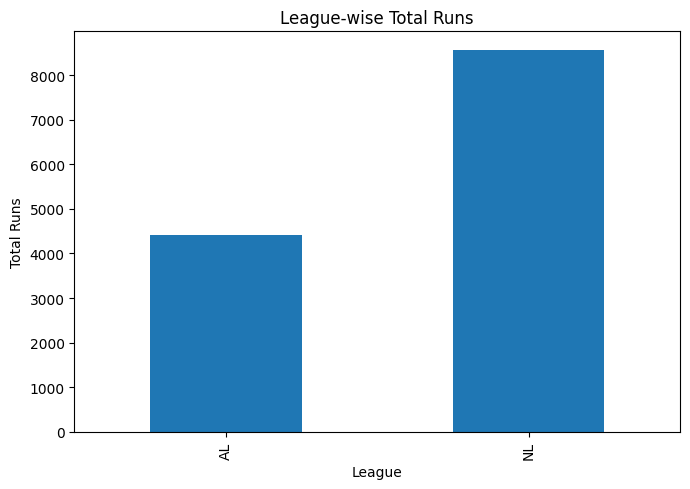

In [9]:
plt.figure(figsize=(7,5))
players.groupby("League")["Runs"].sum().plot(kind="bar")
plt.title("League-wise Total Runs")
plt.xlabel("League")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()